In [2]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var, plot_peak_power_vs_var
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import re
big_plt_font()

In [3]:
home_dir = '/home/electron/'
data_dir = home_dir + f'artiq/experiment/artiq-master/results/2026-07-27'

In [4]:
import os
import h5py 

def load_h5_data(filepath, base=None):
    if base is not None:
        filepath = os.path.join(base, filepath)
        
    data = {}
    try:
        with h5py.File(filepath, 'r') as f:
            def _read_node(node):
                if isinstance(node, h5py.Group):
                    return {k: _read_node(v) for k, v in node.items()}
                elif isinstance(node, h5py.Dataset):
                    # Use np.array(node) instead of node[()] to safely load compound types
                    val = np.array(node)
                    # If it's a 0-D scalar array, unpack it
                    return val.item() if val.shape == () else val
                return None

            for key in f.keys():
                data[key] = _read_node(f[key])
                
    except FileNotFoundError:
        print(f">>> File not found: {filepath}")
    except Exception as e:
        print(f"Error: {e}")
        
    return data

In [5]:
import pandas as pd
import numpy as np

def convert_dict_to_dataframe(data_dict, var_names=None):
    """
    Converts an HDF5 data dictionary with keys formatted like 'data.{var1}.{var2}....{varN}'
    into a structured pandas DataFrame.

    Parameters
    ----------
    data_dict : dict
        Dictionary loaded from HDF5 file.
    var_names : list of str, optional
        Custom column names for [var1, var2, ..., varN]. If None, it attempts 
        to read 'var_names'/'variables' from data_dict, or defaults to ['var1', 'var2', ...].

    Returns
    -------
    df : pandas.DataFrame
        DataFrame with dynamic variable columns, 'data', and 'time' (if present).
    """
    # 1. Infer variable names if not explicitly passed
    if var_names is None:
        for meta_key in ['var_names', 'variables', 'param_names']:
            if meta_key in data_dict:
                var_names = list(data_dict[meta_key])
                break

    # 2. Extract shared time/x-axis array if stored at the root
    time_data = None
    for t_key in ['time', 't', 't_axis', 'x_axis']:
        if t_key in data_dict:
            time_data = data_dict[t_key]
            break

    records = []

    # 3. Parse all dataset keys starting with 'data.' or 'data/'
    for key, value in data_dict['datasets'].items():
        if key.startswith('data.') or key.startswith('data/'):
            # Split tokens after the 'data' prefix
            tokens = key.replace('/', '.').split('.')[1:]
            
            row = {}
            named_tokens = False
            
            # Check if key tokens contain key-value pairs (e.g. "Ex=10" or "Ex_10")
            for idx, token in enumerate(tokens):
                if '=' in token:
                    k, v = token.split('=', 1)
                    row[k] = v
                    named_tokens = True
                elif '_' in token and not token.replace('_', '').replace('-', '').replace('.', '').replace('e', '').isdigit():
                    k, v = token.split('_', 1)
                    row[k] = v
                    named_tokens = True

            # If tokens were not self-named (e.g., 'data.10.20.30'), map positionally
            if not named_tokens:
                for idx, token in enumerate(tokens):
                    col_name = var_names[idx] if (var_names and idx < len(var_names)) else f'var{idx + 1}'
                    row[col_name] = token

            # Attach raw signal and time array
            row['data'] = value
            if time_data is not None:
                row['time'] = time_data

            records.append(row)

    df = pd.DataFrame(records)

    # 4. Automatically convert variable columns to numeric types (int/float)
    for col in df.columns:
        if col not in ['data', 'time']:
            df[col] = pd.to_numeric(df[col], errors='ignore')

    return df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

def compare_sweep_data(data_files, data_dir='', var_names=None, fix_ylim=False):
    """
    Plots interactive curves across dynamically detected variables in HDF5 sweep files,
    with an index control (i) to iterate through sub-arrays / trace batches.
    """
    # 1. Load all files into a single master DataFrame
    df_list = []
    print("Scanning HDF5 datasets...")
    for filepath in data_files:
        try:
            data_dict = load_h5_data(filepath, base=data_dir)
            df = convert_dict_to_dataframe(data_dict, var_names=var_names)
            df['_filepath'] = filepath
            df_list.append(df)
        except Exception as e:
            print(f"Skipping {filepath} due to error: {e}")

    if not df_list:
        print("No valid data loaded.")
        return

    master_df = pd.concat(df_list, ignore_index=True)

    # Identify parameter columns (excluding internal/data/time columns)
    param_cols = [c for c in master_df.columns if c not in ['data', 'time', '_filepath']]
    print(f"Scan complete. Recognized variables: {param_cols}")

    # Calculate global y-limits across all sub-arrays
    global_y_min, global_y_max = float('inf'), float('-inf')
    for raw_data in master_df['data'].values:
        y_arr = np.array(raw_data)
        if y_arr.size > 0:
            global_y_min = min(global_y_min, np.min(y_arr))
            global_y_max = max(global_y_max, np.max(y_arr))

    has_global_limits = (global_y_min != float('inf') and global_y_max != float('-inf'))
    if has_global_limits:
        y_range = global_y_max - global_y_min
        padding = y_range * 0.05 if y_range > 0 else 1.0
        global_y_min -= padding
        global_y_max += padding
    else:
        global_y_min, global_y_max = -100, 10

    # 2. Build UI Dropdowns for Parameter Variables
    var_dropdowns = {}
    for col in param_cols:
        unique_vals = sorted(master_df[col].dropna().unique())
        var_dropdowns[col] = widgets.Dropdown(
            options=unique_vals,
            description=f'{col}:',
            style={'description_width': 'initial'}
        )

    # 3. Trace Index (i) Widgets
    trace_idx_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=29,  # Will adjust dynamically based on array length
        step=1,
        description='Trace (i):',
        continuous_update=False,
        style={'description_width': 'initial'}
    )

    btn_trace_prev = widgets.Button(description='Prev Trace', button_style='info', icon='arrow-left')
    btn_trace_next = widgets.Button(description='Next Trace', button_style='primary', icon='arrow-right')

    fix_ylim_checkbox = widgets.Checkbox(
        value=fix_ylim,
        description='Fix Y-Axis Limits',
        disabled=not has_global_limits,
        indent=False
    )

    plot_output = widgets.Output()

    # 4. Drawing Logic
    def draw_plot(change=None):
        # Filter master_df based on variable dropdown selections
        filtered_df = master_df.copy()
        current_selection = {}
        for col, dropdown in var_dropdowns.items():
            val = dropdown.value
            current_selection[col] = val
            if val is not None:
                if isinstance(val, (int, float, np.number)):
                    filtered_df = filtered_df[np.isclose(filtered_df[col].astype(float), float(val), atol=1e-5)]
                else:
                    filtered_df = filtered_df[filtered_df[col] == val]

        with plot_output:
            clear_output(wait=True)
            if filtered_df.empty:
                print(f"No configuration found matching: {current_selection}")
                return

            row = filtered_df.iloc[0]
            raw_data = np.array(row['data'])

            # Multi-trace array indexing check
            if raw_data.ndim > 1:
                num_traces = raw_data.shape[0]
                # Update slider upper bound dynamically
                if trace_idx_slider.max != num_traces - 1:
                    trace_idx_slider.max = max(0, num_traces - 1)

                i = min(trace_idx_slider.value, num_traces - 1)
                y_data = raw_data[i]
                trace_info = f" | Trace i = {i}/{num_traces - 1}"
            else:
                y_data = raw_data
                trace_info = ""

            # Extract time/x-axis vector
            if 'time' in row and row['time'] is not None:
                t_data = np.array(row['time'])
                t_axis = t_data[i] if (t_data.ndim > 1 and t_data.shape[0] == raw_data.shape[0]) else t_data
            else:
                t_axis = np.arange(len(y_data))

            # Plotting
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(t_axis, y_data, color='blue', lw=2)

            if fix_ylim_checkbox.value:
                ax.set_ylim(global_y_min, global_y_max)

            title_params = " | ".join([f"{k}: {v}" for k, v in current_selection.items()])
            ax.set_title(f"{title_params}{trace_info}")
            ax.set_xlabel("Time / Index")
            ax.set_ylabel("Signal")
            ax.grid(True)
            plt.show()

    # 5. Trace Navigation Buttons
    def on_prev_trace(b):
        if trace_idx_slider.value > trace_idx_slider.min:
            trace_idx_slider.value -= 1

    def on_next_trace(b):
        if trace_idx_slider.value < trace_idx_slider.max:
            trace_idx_slider.value += 1

    # 6. Bind Observers & Handlers
    for dd in var_dropdowns.values():
        dd.observe(draw_plot, names='value')
        
    trace_idx_slider.observe(draw_plot, names='value')
    fix_ylim_checkbox.observe(lambda c: draw_plot(), names='value')

    btn_trace_prev.on_click(on_prev_trace)
    btn_trace_next.on_click(on_next_trace)

    # 7. Layout Assembly
    dropdown_widgets = list(var_dropdowns.values())
    param_controls = widgets.HBox(dropdown_widgets)
    trace_controls = widgets.HBox([btn_trace_prev, trace_idx_slider, btn_trace_next, fix_ylim_checkbox])

    ui = widgets.VBox([
        param_controls,
        trace_controls,
        plot_output
    ])

    display(ui)
    draw_plot()

In [159]:
filename = 'artiq/experiment/artiq-master/results/2026-07-30/16/000010774-FeedbackWithSingleConfig.h5'
compare_sweep_data([filename], data_dir=home_dir)

Scanning HDF5 datasets...
>>> File not found: /home/electron/artiq/experiment/artiq-master/results/2026-07-30/16/000010774-FeedbackWithSingleConfig.h5
Skipping artiq/experiment/artiq-master/results/2026-07-30/16/000010774-FeedbackWithSingleConfig.h5 due to error: 'datasets'
No valid data loaded.


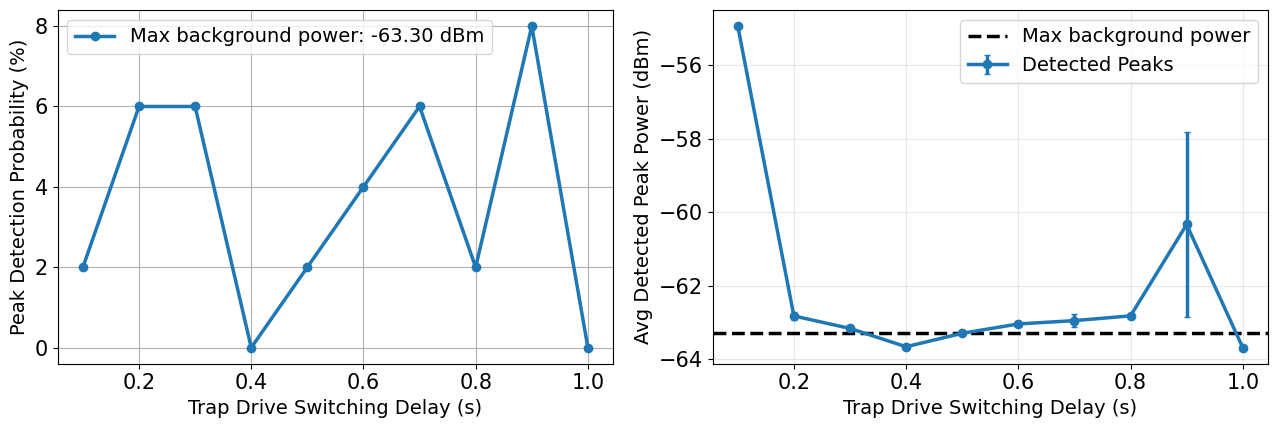

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py
import pandas as pd
import numpy as np

def load_structured_h5(filepath):
    """
    Loads an ARTIQ HDF5 file saved with structured/2D arrays ('scan_data' and 't_data').
    Returns:
        df: pd.DataFrame containing driving parameters, rep_idx, and trace data.
        t_axis: np.ndarray 1D time vector.
    """
    with h5py.File(filepath, 'r') as f:
        # ARTIQ places datasets under 'datasets/'
        scan_data = f['datasets/scan_data'][:]
        
        if 'datasets/t_data' in f:
            t_axis = f['datasets/t_data'][:]
        else:
            t_axis = None
    
    # --- 1. Fix ARTIQ's (N, 1) append shape wrapper ---
    if scan_data.ndim > 1:
        scan_data = scan_data.squeeze()

    # If squeeze reduced 1 sample down to 0-D scalar, turn back to 1D
    if scan_data.ndim == 0:
        scan_data = np.array([scan_data])

    # --- 2. Convert Structured Array to Pandas DataFrame ---
    if scan_data.dtype.names is not None:
        # Extract record fields explicitly to avoid shape mismatch issues
        data_dict = {name: scan_data[name] for name in scan_data.dtype.names}
        
        # Unpack traces into a clean Python list of 1D arrays
        if 'trace' in data_dict:
            data_dict['trace'] = [np.atleast_1d(t) for t in data_dict['trace']]
            
        df = pd.DataFrame(data_dict)
    else:
        # Fallback for raw matrices (120 reps x N time points)
        rows = [{'rep_idx': idx, 'trace': trace} for idx, trace in enumerate(scan_data)]
        df = pd.DataFrame(rows)

    # --- 3. Process & Validate Time Axis ---
    if t_axis is not None:
        if t_axis.ndim > 1:
            t_axis = t_axis.squeeze()
        if t_axis.ndim > 1:  # If multi-dimensional array saved per rep
            t_axis = t_axis[0]
    else:
        # Fallback time axis generation based on trace length if missing
        trace_len = len(df['trace'].iloc[0])
        t_axis = np.arange(trace_len, dtype=np.float64)

    df['_filepath'] = filepath
    return df, t_axis

def plot_detection_and_power(
    data_files, bg_files, scan_var, unit="nW", home_dir=None
):
    """Plots trace detection probability (fraction of traces with max power > 5 sigma of background)

    and average detected max power with SEM error bars across a specified scanning variable.
    """
    # 1. Ensure inputs are lists even if passed as single string filepaths
    data_files_list = (
        [data_files] if isinstance(data_files, str) else list(data_files)
    )
    bg_files_list = (
        [bg_files] if isinstance(bg_files, str) else list(bg_files)
    )

    # 2. Load Background Data & Compute 5-Sigma Threshold
    bg_traces_list = []
    for bg_fp in bg_files_list:
        file = (
            load_h5_data(bg_fp, base=home_dir)
            if home_dir
            else load_h5_data(bg_fp)
        )
        y_bg = np.concatenate([
            file["datasets"][i]
            for i in file["datasets"]
            if str(i).startswith("data")
        ]).flatten()
        bg_traces_list.append(y_bg)

    bg_traces_raw = np.concatenate(bg_traces_list)

    if unit == "nW":
        bg_signals = dbm_to_nw(bg_traces_raw)
    else:
        bg_signals = bg_traces_raw

    thresh_5sigma = np.max(bg_signals)
    # 3. Load Signal Data
    df_list = []
    for fp in data_files_list:
        df_single, _ = load_structured_h5(fp)
        df_list.append(df_single)

    master_df = pd.concat(df_list, ignore_index=True)

    if scan_var not in master_df.columns:
        raise ValueError(
            f"Scanning variable '{scan_var}' not found in dataframe columns: {list(master_df.columns)}"
        )

    # 4. Process Data Across Scan Variable (Trace-Level)
    x_vals = np.array(sorted(master_df[scan_var].dropna().unique()))

    probs = []
    mean_powers = []
    sem_powers = []

    for x_val in x_vals:
        sub_df = master_df[np.isclose(master_df[scan_var], x_val, atol=1e-5)]

        if sub_df.empty:
            probs.append(np.nan)
            mean_powers.append(np.nan)
            sem_powers.append(np.nan)
            continue

        # Stack traces into a 2D matrix: shape (n_traces, n_timepoints)
        traces_matrix = np.vstack(sub_df["trace"].values)

        if unit == "nW":
            traces_matrix = dbm_to_nw(traces_matrix)

        # Calculate max power for EACH individual trace
        max_power_per_trace = np.max(traces_matrix, axis=1)

        # Trace detection condition: max power > 5-sigma threshold
        detected_mask = max_power_per_trace > thresh_5sigma

        # Probability = (Number of traces with max > 5sigma) / (Total traces)
        prob = np.mean(detected_mask)
        probs.append(prob)

        # Average peak power of only the detected traces
        detected_max_powers = max_power_per_trace[detected_mask]
        if len(detected_max_powers) > 0:
            mean_powers.append(np.mean(detected_max_powers))
            sem = (
                np.std(detected_max_powers, ddof=1)
                / np.sqrt(len(detected_max_powers))
                if len(detected_max_powers) > 1
                else 0.0
            )
            sem_powers.append(sem)
        else:
            mean_powers.append(np.max(max_power_per_trace))
            sem_powers.append(np.nan)

    probs = np.array(probs)
    mean_powers = np.array(mean_powers)
    sem_powers = np.array(sem_powers)

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    # --- Plot 1: Trace Detection Probability ---
    ax1.plot(
        x_vals,
        probs*100,
        "o-",
        markersize=6,
        color="#1f77b4",
        label=f"Max background power: {thresh_5sigma:.2f} {unit}",
    )
    ax1.set_xlabel('Trap Drive Switching Delay (s)')
    ax1.set_ylabel(
        r"Peak Detection Probability (%)"
    )
    # ax1.set_title(
    #     "Trace Detection Probability (> 5σ)", fontsize=12, fontweight="bold"
    # )
    # ax1.set_yscale('log')
    ax1.grid(True)
    ax1.legend(loc="best")

    # --- Plot 2: Average Detected Peak Power ---
    ax2.errorbar(
        x_vals,
        mean_powers,
        yerr=sem_powers,
        fmt="o-",
        # color="#d62728",
        # ecolor="black",
        # capsize=4,
        # capthick=1.2,
        # linewidth=2,
        markersize=6,
        label="Detected Peaks",
    )
    ax2.axhline(thresh_5sigma, linestyle='--', color='k', label='Max background power')
    ax2.set_xlabel('Trap Drive Switching Delay (s)')
    ax2.set_ylabel(f"Avg Detected Peak Power ({unit})")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()
plot_detection_and_power('/home/electron/artiq/experiment/artiq-master/results/2026-07-28/23/000010640-LoadingWithDelayedTrapDriveSwitching.h5', 
                         '/home/electron/artiq/experiment/artiq-master/results/2026-07-28/22/000010638-LoadingWithtriggeredDriving.h5', 
                         't_trap_drive_delay', unit='dBm')

In [87]:
file = load_h5_data(filename, base=home_dir) 
all_max = [] 
all_max_postdriving = []
t = file['datasets']['t_data']
for i in file['datasets']: 
    if i[:4] == 'data': 
        for j in file['datasets'][i]: 
            all_max.append(max(j))
            if max(j) >= -63: 
                all_max_postdriving.append(max(j[(np.argmax(j)//751+1)*751:]))

y = np.concatenate([file['datasets'][i] for i in file['datasets'] if i[:4] == 'data']).flatten()
plt.hist(y, bins=50, histtype='step', lw=2, label='All data', density=True)
plt.hist(np.array(all_max), bins=50, density=True, label='Max power') 
plt.hist(np.array(all_max_postdriving), density=True, bins=20, label='Max power post peak')
plt.yscale('log') 
plt.grid()
plt.xlabel('Detected Power (dBm)') 
plt.ylabel('Probability Density') 
plt.legend() 
plt.tight_layout() 
plt.show()

ValueError: max() arg is an empty sequence

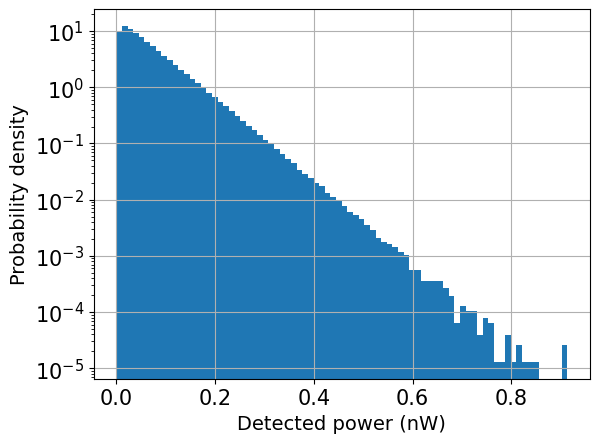

In [156]:
filename = 'artiq/experiment/artiq-master/results/2026-07-30/16/000010688-LoadingWithtriggeredDrivingAndStepping.h5'
file = load_h5_data(filename, base=home_dir)
y = np.concatenate([file['datasets'][i] for i in file['datasets'] if i[:4] == 'data']).flatten()
plt.hist(10**(y/10)*1e6, density=True, bins=80)
plt.yscale('log')
plt.grid()
plt.xlabel('Detected power (nW)') 
plt.ylabel('Probability density')
plt.show()

In [169]:
max(y), np.mean(y), np.std(y), max(10**(y/10)*1e6), np.mean(10**(y/10)*1e6), np.std(10**(y/10)*1e6)

(-63.30472,
 -75.7745602030892,
 4.6553090026461215,
 0.46722707344348396,
 0.04210417904365538,
 0.03959377950170426)

In [94]:
signal_files = ['artiq/experiment/artiq-master/results/2026-07-28/22/000010638-LoadingWithtriggeredDriving.h5',
                'artiq/experiment/artiq-master/results/2026-07-28/19/000010634-LoadingWithtriggeredDriving.h5', 
                'artiq/experiment/artiq-master/results/2026-07-28/18/000010633-LoadingWithtriggeredDriving.h5', 
                'artiq/experiment/artiq-master/results/2026-07-28/18/000010632-LoadingWithtriggeredDriving.h5', 
                'artiq/experiment/artiq-master/results/2026-07-28/16/000010629-LoadingWithRFScans.h5', 
                'artiq/experiment/artiq-master/results/2026-07-28/11/000010621-LoadingWithDelayedTrapDrive.h5', 
                'artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5'] 

all_sig = [] 
all_t_sig = []
for filename in signal_files: 
    file = load_h5_data(filename, base=home_dir) 
    tax = file['datasets']['t_data']
    for i in file['datasets']: 
        if i[:4] == 'data': 
            for y in file['datasets'][i]: 
                if max(y) >= -63: 
                    if tax[0] > tax[np.argmax(y)]-0.005: 
                        continue
                    idx = np.where((tax>tax[np.argmax(y)]-0.005)&(tax<tax[np.argmax(y)]+0.005))
                    all_sig.append(y[idx]) 
                    all_t_sig.append(tax[idx]) 
all_t_sig = np.array(all_t_sig)*1e3

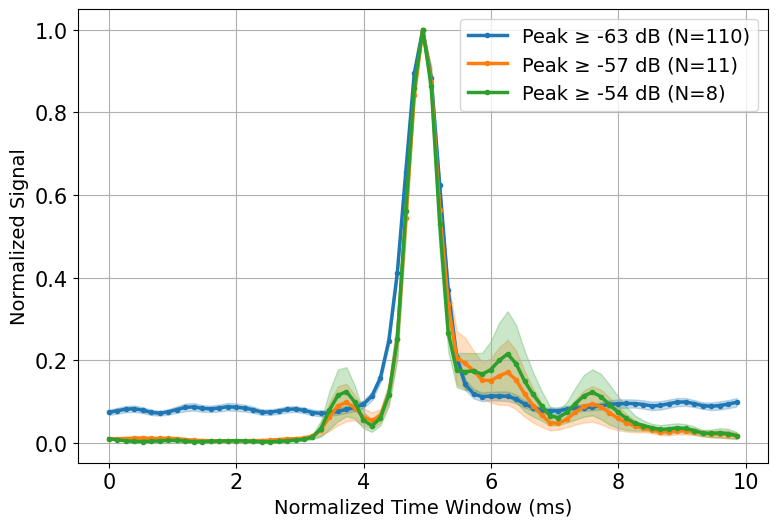

In [151]:
import matplotlib.pyplot as plt
import numpy as np

signal_files = [
    'artiq/experiment/artiq-master/results/2026-07-28/22/000010638-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/19/000010634-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/18/000010633-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/18/000010632-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/16/000010629-LoadingWithRFScans.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/11/000010621-LoadingWithDelayedTrapDrive.h5',
    'artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5',
]

# ==========================================
# 1. PRE-LOAD DATA ONCE
# ==========================================
raw_traces = []
for filename in signal_files:
    file = load_h5_data(filename, base=home_dir)
    tax = file['datasets']['t_data']
    for key in file['datasets']:
        if key.startswith('data'):
            for y in file['datasets'][key]:
                raw_traces.append((tax, y))

# ==========================================
# 2. LOOP OVER THRESHOLDS & PLOT
# ==========================================
thresholds = [-63, -57, -54]

plt.figure(figsize=(8, 5.5))

for thresh in thresholds:
    all_sig = []
    all_t_sig = []

    for tax, y in raw_traces:
        if max(y) >= thresh:
            max_idx = np.argmax(y)
            t_max = tax[max_idx]

            if tax[0] > t_max - 0.005:
                continue

            idx = np.where((tax > t_max - 0.005) & (tax < t_max + 0.005))[0]
            all_sig.append(y[idx])
            all_t_sig.append(tax[idx])

    if len(all_sig) == 0:
        print(f"No traces found for threshold {thresh} dB")
        continue

    all_sig = np.array(all_sig)
    all_t_sig = np.array(all_t_sig) * 1e3  # convert time to ms

    # Normalized linear signals and error bar calculation
    sig_linear = 10 ** (all_sig / 10)
    sig_norm = sig_linear.T / np.max(sig_linear, axis=1)

    data = np.mean(sig_norm, axis=1)
    err_bar = np.std(sig_norm, axis=1) / np.sqrt(len(all_sig))
    t_axis = all_t_sig[0] - all_t_sig[0][0]

    # Plot line
    (line,) = plt.plot(
        t_axis,
        data,
        '.-',
        markersize=6,
        label=f'Peak ≥ {thresh} dB (N={len(all_sig)})',
    )

    # Shade error bar region (± SEM) with matching curve color
    plt.fill_between(
        t_axis,
        data - err_bar,
        data + err_bar,
        color=line.get_color(),
        alpha=0.25,
    )

plt.xlabel('Normalized Time Window (ms)')
plt.ylabel('Normalized Signal')
# plt.title('Normalized Signals Comparison Across Thresholds')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

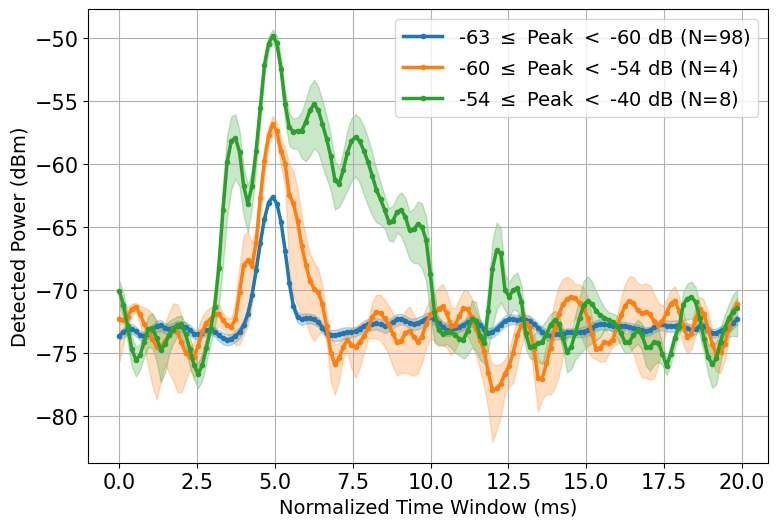

In [150]:
import matplotlib.pyplot as plt
import numpy as np

signal_files = [
    'artiq/experiment/artiq-master/results/2026-07-28/22/000010638-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/19/000010634-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/18/000010633-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/18/000010632-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/16/000010629-LoadingWithRFScans.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/11/000010621-LoadingWithDelayedTrapDrive.h5',
    'artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5',
]

# ==========================================
# 1. PRE-LOAD DATA ONCE
# ==========================================
raw_traces = []
for filename in signal_files:
    file = load_h5_data(filename, base=home_dir)
    tax = file['datasets']['t_data']
    for key in file['datasets']:
        if key.startswith('data'):
            for y in file['datasets'][key]:
                raw_traces.append((tax, y))

# ==========================================
# 2. LOOP OVER THRESHOLDS & PLOT
# ==========================================
thresholds = [-63, -60, -54]

plt.figure(figsize=(8, 5.5))
i = 0
for thresh in thresholds:
    all_sig = []
    all_t_sig = []

    for tax, y in raw_traces:
        thres_2 = thresholds[i+1] if i < 2 else -40
        if max(y) >= thresh and max(y) < thres_2:
            max_idx = np.argmax(y)
            t_max = tax[max_idx]

            if tax[0] > t_max - 0.005:
                continue

            idx = np.where((tax > t_max - 0.005) & (tax < t_max + 0.015))[0]
            all_sig.append(y[idx])
            all_t_sig.append(tax[idx])

    if len(all_sig) == 0:
        print(f"No traces found for threshold {thresh} dB")
        continue

    all_sig = np.array(all_sig)
    all_t_sig = np.array(all_t_sig) * 1e3  # convert time to ms

    # Normalized linear signals and error bar calculation
    sig_linear = 10 ** (all_sig / 10)
    sig_norm = sig_linear.T #/ np.max(sig_linear, axis=1)

    data = np.mean(sig_norm, axis=1)
    err_bar = np.std(sig_norm, axis=1) / np.sqrt(len(all_sig))
    t_axis = all_t_sig[0] - all_t_sig[0][0]

    # Plot line
    (line,) = plt.plot(
        t_axis,
        10*np.log10(data),
        '.-',
        markersize=6,
        label=f'{thresh} $\leq$ Peak $<$ {thres_2} dB (N={len(all_sig)})',
    )

    # Shade error bar region (± SEM) with matching curve color
    plt.fill_between(
        t_axis,
        10*np.log10(data - err_bar),
        10*np.log10(data + err_bar),
        color=line.get_color(),
        alpha=0.25,
    )
    i += 1
plt.xlabel('Normalized Time Window (ms)')
plt.ylabel('Detected Power (dBm)')
# plt.title('Normalized Signals Comparison Across Thresholds')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [131]:
signal_files = [
    'artiq/experiment/artiq-master/results/2026-07-28/22/000010638-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/19/000010634-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/18/000010633-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/18/000010632-LoadingWithtriggeredDriving.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/16/000010629-LoadingWithRFScans.h5',
    'artiq/experiment/artiq-master/results/2026-07-28/11/000010621-LoadingWithDelayedTrapDrive.h5',
    'artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5',
]

# ==========================================
# 1. PRE-LOAD DATA ONCE
# ==========================================
max_val = []
t_entr = []
for filename in signal_files:
    file = load_h5_data(filename, base=home_dir)
    tax = file['datasets']['t_data']
    for key in file['datasets']:
        if key.startswith('data'):
            for y in file['datasets'][key]:
                if max(y) > -63:
                    max_val.append(max(y))
                    t_entr.append(tax[np.argmax(y)]*1e3)

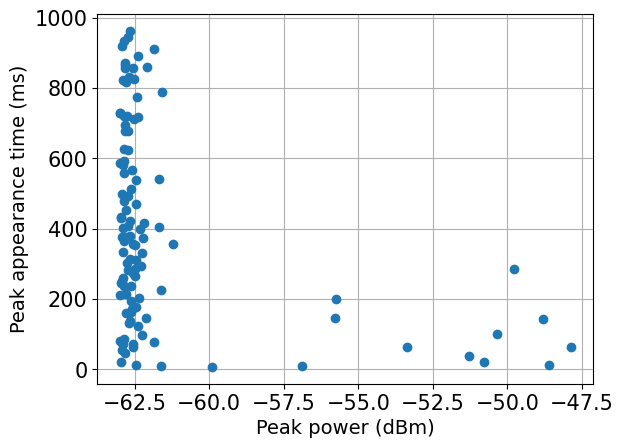

In [134]:
plot(max_val, t_entr, '.', xlabel='Peak power (dBm)', ylabel='Peak appearance time (ms)')
# plt.yscale('log')

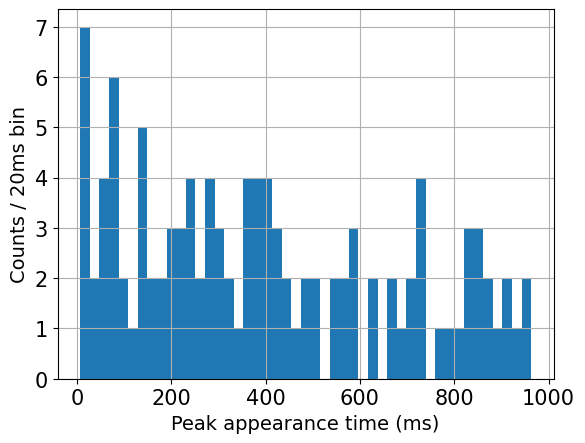

In [149]:
plt.hist(t_entr, bins=int((max(t_entr)-min(t_entr))/20))
plt.xlabel('Peak appearance time (ms)') 
plt.ylabel('Counts / 20ms bin')
plt.grid()
plt.show()

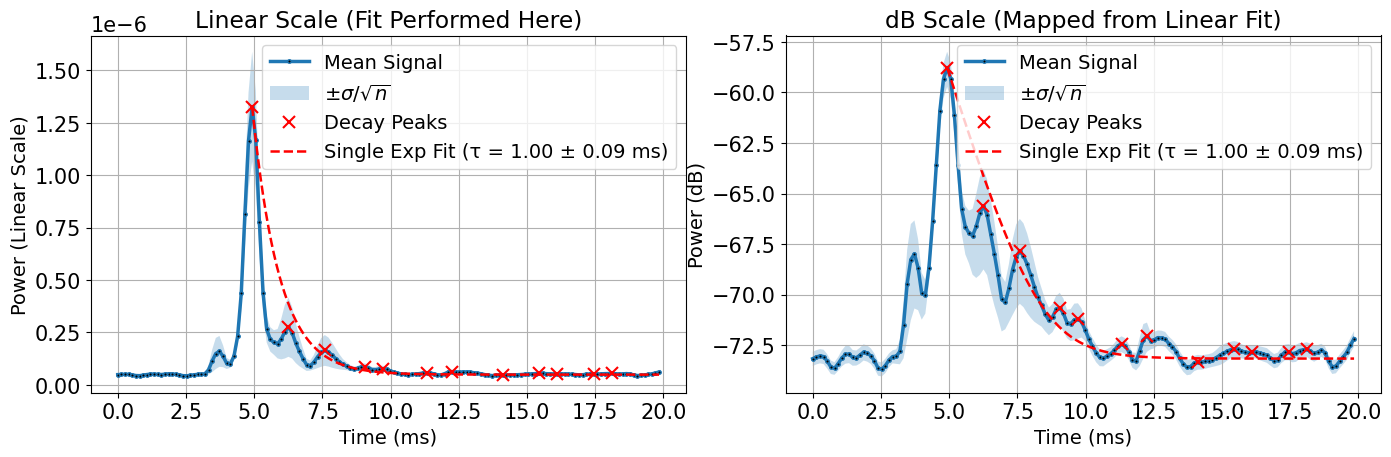

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# ==========================================
# 1. DATA PREPARATION (LINEAR SCALE)
# ==========================================
# Convert signals to linear power (nW or W)
power_linear_all = 10 ** (np.array(all_sig) / 10)
power_linear_mean = np.mean(power_linear_all, axis=0)
t_axis = np.array(all_t_sig[0]) - all_t_sig[0][0]

# Standard error in linear scale
sem_linear = np.std(power_linear_all, axis=0) / np.sqrt(len(all_sig))

# Peak detection in linear domain
peaks, _ = find_peaks(
    power_linear_mean, height=np.max(power_linear_mean) * 0.01, distance=5
)
global_max_idx = np.argmax(power_linear_mean)
decay_peaks = peaks[peaks >= global_max_idx]

t_decay = t_axis[decay_peaks]
power_decay = power_linear_mean[decay_peaks]


# ==========================================
# 2. SINGLE EXPONENTIAL DECAY FIT (LINEAR DOMAIN)
# ==========================================
def single_exp_decay(t_val, A, tau, C):
    """Pure single exponential decay + baseline offset."""
    return A * np.exp(-(t_val - t_decay[0]) / tau) + C


# Baseline noise estimate from pre-trigger region (t < 2.5 ms)
baseline_guess = np.mean(power_linear_mean[t_axis < 2.5])

p0 = [power_decay[0] - baseline_guess, 1.0, baseline_guess]
bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

# Fit single exponential directly to linear peak points
popt, pcov = curve_fit(
    single_exp_decay, t_decay, power_decay, p0=p0, bounds=bounds
)
A_fit, tau_fit, C_fit = popt
tau_err = np.sqrt(np.diag(pcov))[1]

# Generate smooth fit curve
t_fit_smooth = np.linspace(t_decay[0], t_axis[-1], 300)
fit_linear_smooth = single_exp_decay(t_fit_smooth, *popt)
fit_db_smooth = 10 * np.log10(np.maximum(1e-15, fit_linear_smooth))

# ==========================================
# 3. SIDE-BY-SIDE PLOTTING
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT PLOT: LINEAR SCALE ---
ax[0].plot(
    t_axis,
    power_linear_mean,
    ".-",
    markersize=5,
    markerfacecolor="k",
    label="Mean Signal",
)
ax[0].fill_between(
    t_axis,
    power_linear_mean - sem_linear,
    power_linear_mean + sem_linear,
    alpha=0.25,
    label=r"$\pm\sigma/\sqrt{n}$",
)
ax[0].plot(
    t_decay,
    power_decay,
    "rx",
    markersize=8,
    mew=1.5,
    label="Decay Peaks",
)
ax[0].plot(
    t_fit_smooth,
    fit_linear_smooth,
    "r--",
    linewidth=1.8,
    label=f"Single Exp Fit (τ = {tau_fit:.2f} ± {tau_err:.2f} ms)",
)
ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Power (Linear Scale)")
ax[0].set_title("Linear Scale (Fit Performed Here)")
ax[0].legend(loc="upper right")
ax[0].grid(True)

# --- RIGHT PLOT: dB SCALE ---
mean_db = 10 * np.log10(power_linear_mean)
lower_db = 10 * np.log10(np.maximum(1e-15, power_linear_mean - sem_linear))
upper_db = 10 * np.log10(power_linear_mean + sem_linear)

ax[1].plot(
    t_axis,
    mean_db,
    ".-",
    markersize=5,
    markerfacecolor="k",
    label="Mean Signal",
)
ax[1].fill_between(
    t_axis, lower_db, upper_db, alpha=0.25, label=r"$\pm\sigma/\sqrt{n}$"
)
ax[1].plot(
    t_decay,
    mean_db[decay_peaks],
    "rx",
    markersize=8,
    mew=1.5,
    label="Decay Peaks",
)
ax[1].plot(
    t_fit_smooth,
    fit_db_smooth,
    "r--",
    linewidth=1.8,
    label=f"Single Exp Fit (τ = {tau_fit:.2f} ± {tau_err:.2f} ms)",
)
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Power (dB)")
ax[1].set_title("dB Scale (Mapped from Linear Fit)")
ax[1].legend(loc="upper right")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [182]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider


def jupyter_plot_stepper(all_t_sig, all_sig):
    @interact(
        i=IntSlider(
            min=0, max=len(all_sig) - 1, step=1, value=0, description="Trace:"
        )
    )
    def show_plot(i):
        plt.figure(figsize=(8, 4))
        plt.plot(all_t_sig[i], all_sig[i], ".-")
        plt.title(f"Trace {i + 1} of {len(all_sig)}")
        plt.xlabel("Time (s)")
        plt.ylabel("Signal")
        plt.grid(True)
        plt.show()


# Example usage in Jupyter:
jupyter_plot_stepper(all_t_sig, all_sig)

interactive(children=(IntSlider(value=0, description='Trace:', max=106), Output()), _dom_classes=('widget-inte…

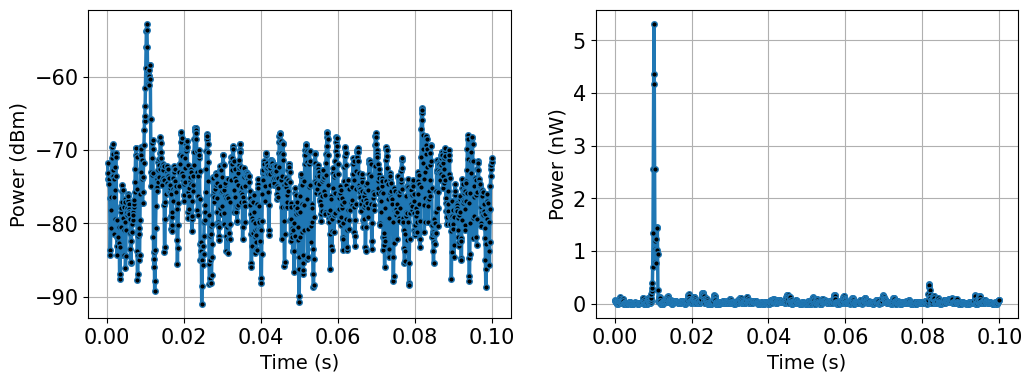

In [92]:
file = load_h5_data(filename, base=home_dir)
y = file['datasets']['data.353MHz.17dB'][15]
t = file['datasets'][
idx = np.where((t>0.0)&(t<0.1))
fig, ax = plt.subplots(ncols=2, figsize=(12,4))
plot_ax(ax[0], t[idx], y[idx], '.-', xlabel='Time (s)', ylabel='Power (dBm)', markersize=8, markerfacecolor='k')
plot_ax(ax[1], t[idx], 10**(y[idx]/10)*1e6, '.-', xlabel='Time (s)', ylabel='Power (nW)', markersize=8, markerfacecolor='k')

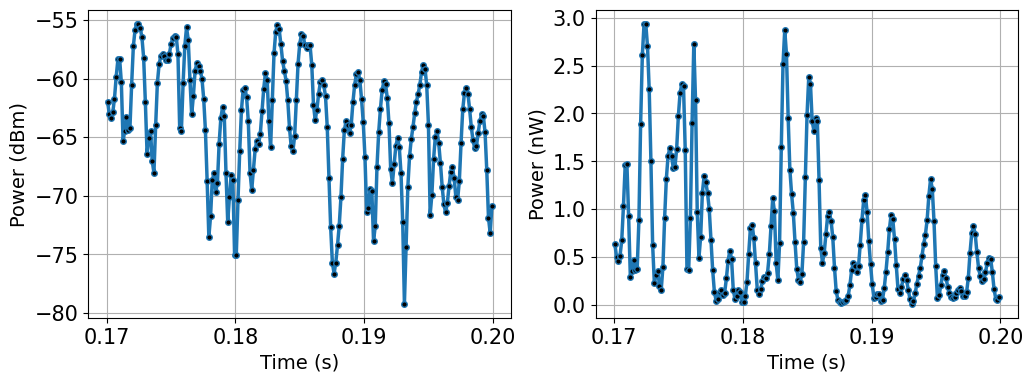

In [56]:
file = load_h5_data('artiq/experiment/artiq-master/results/2026-07-27/08/000010596-LoadingWithDelayedDriving.h5', base=home_dir)
y = file['datasets']['data.353MHz.17dB'][4]
t = np.linspace(0, 0.6, len(y))
idx = np.where((t>0.17)&(t<0.20))
fig, ax = plt.subplots(ncols=2, figsize=(12,4))
plot_ax(ax[0], t[idx], y[idx], '.-', xlabel='Time (s)', ylabel='Power (dBm)', markersize=8, markerfacecolor='k')
plot_ax(ax[1], t[idx], 10**(y[idx]/10)*1e6, '.-', xlabel='Time (s)', ylabel='Power (nW)', markersize=8, markerfacecolor='k')

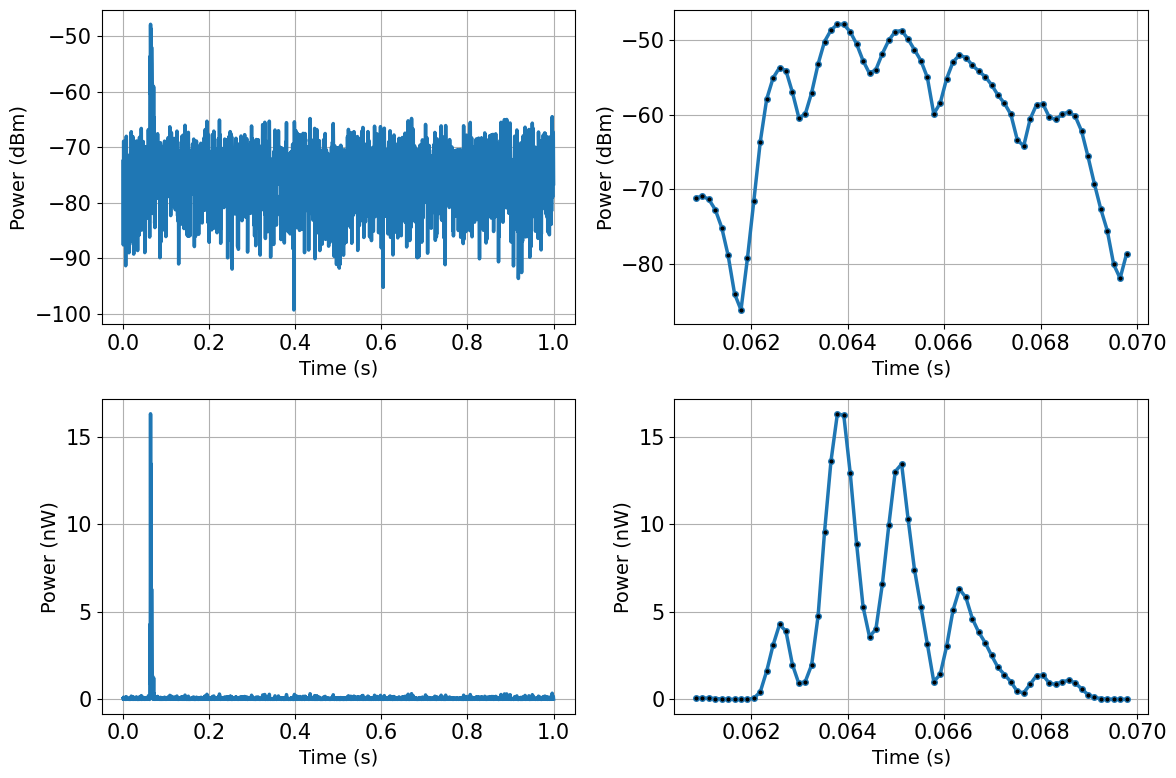

In [144]:
file = load_h5_data('artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5', base=home_dir)
y = file['datasets']['data.Ex__0p8.Ey__0p10000000000000009.Ez__0p10000000000000009.U1__-0p45.U2__-0p5499999999999999.U3__0p0.U4__0p0.U5__0p0'][22]
tax = file['datasets']['t_data']
idx = np.where((tax>tax[np.argmax(y)]-0.003)&(tax<tax[np.argmax(y)]+0.006))
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12,8))
plot_ax(ax[0][0], tax, y, '-', xlabel='Time (s)', ylabel='Power (dBm)')
plot_ax(ax[1][0], tax, 10**(y/10)*1e6, '-', xlabel='Time (s)', ylabel='Power (nW)', markersize=8, markerfacecolor='k')
plot_ax(ax[0][1], tax[idx], y[idx], '.-', xlabel='Time (s)', ylabel='Power (dBm)', markersize=8, markerfacecolor='k')
plot_ax(ax[1][1], tax[idx], 10**(y[idx]/10)*1e6, '.-', xlabel='Time (s)', ylabel='Power (nW)', markersize=8, markerfacecolor='k')
plt.tight_layout() 
plt.show()

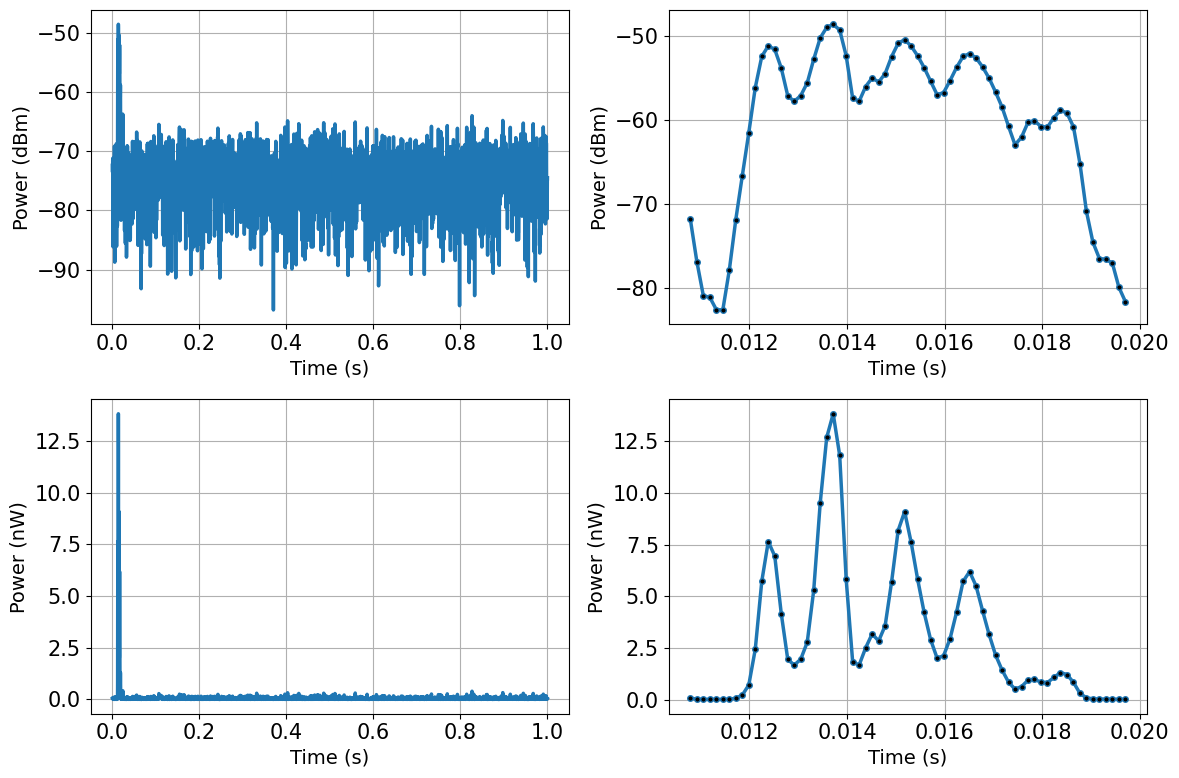

In [161]:
file = load_h5_data('artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5', base=home_dir)
y = file['datasets']['data.Ex__0p30000000000000004.Ey__0p20000000000000007.Ez__0p20000000000000007.U1__-0p45.U2__-0p5999999999999999.U3__0p0.U4__0p0.U5__0p0'][0]
tax = file['datasets']['t_data']
idx = np.where((tax>tax[np.argmax(y)]-0.003)&(tax<tax[np.argmax(y)]+0.006))
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12,8))
plot_ax(ax[0][0], tax, y, '-', xlabel='Time (s)', ylabel='Power (dBm)')
plot_ax(ax[1][0], tax, 10**(y/10)*1e6, '-', xlabel='Time (s)', ylabel='Power (nW)', markersize=8, markerfacecolor='k')
plot_ax(ax[0][1], tax[idx], y[idx], '.-', xlabel='Time (s)', ylabel='Power (dBm)', markersize=8, markerfacecolor='k')
plot_ax(ax[1][1], tax[idx], 10**(y[idx]/10)*1e6, '.-', xlabel='Time (s)', ylabel='Power (nW)', markersize=8, markerfacecolor='k')
plt.tight_layout() 
plt.show()

=== Peak-to-Peak Method ===
Found 4 main peaks at times: [0.012385 0.013717 0.015182 0.016514] s
Average Period (T): 1.376 ms
Ringing Frequency:  726.68 Hz

=== FFT Spectrum Method ===
Dominant Ringing Frequency: 110.43 Hz


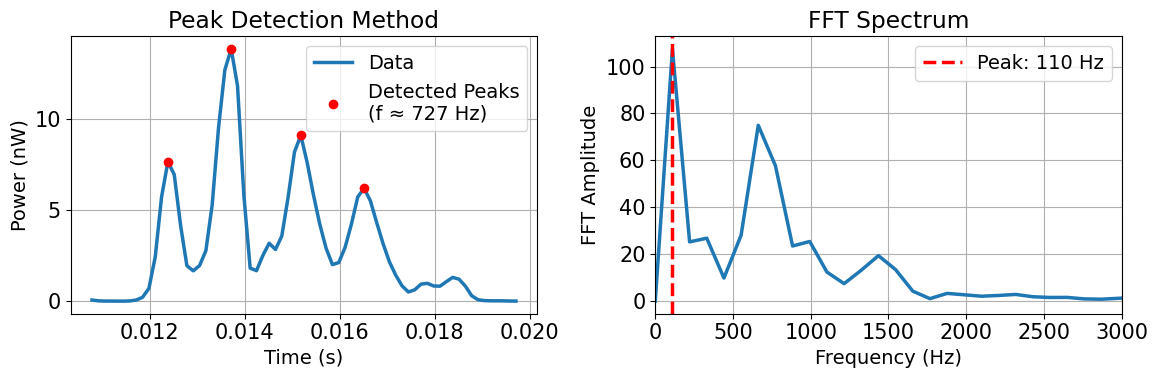

In [162]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# ==========================================
# 1. LOAD YOUR DATA
# Replace these with your actual numpy arrays or dataframe columns
# t: time array in seconds (e.g., 0.005 to 0.015)
# power: power array in nW
# ==========================================
# t = ...
# power = ...


# ==========================================
# METHOD 1: Peak-to-Peak Time Difference
# ==========================================
# Prominence or height filter ensures you only capture the main ringing peaks
power = 10**(y[idx]/10)*1e6
t = tax[idx]
peaks, _ = find_peaks(power, height=1.5, distance=10)

# Calculate period T between successive peaks
peak_times = t[peaks]
periods = np.diff(peak_times)  # Δt between peaks
mean_period = np.mean(periods)  # Average period T
freq_peaks = 1.0 / mean_period  # Frequency f = 1/T

print("=== Peak-to-Peak Method ===")
print(f"Found {len(peaks)} main peaks at times: {np.round(peak_times, 6)} s")
print(f"Average Period (T): {mean_period * 1e3:.3f} ms")
print(f"Ringing Frequency:  {freq_peaks:.2f} Hz\n")


# ==========================================
# METHOD 2: Fast Fourier Transform (FFT)
# ==========================================
# Calculate sampling interval and sampling frequency
dt = np.mean(np.diff(t))
fs = 1.0 / dt

# Subtract baseline/mean to eliminate DC offset (0 Hz spike)
signal_detrended = power - np.mean(power)

# Compute Real FFT
fft_spectrum = np.abs(np.fft.rfft(signal_detrended))
freqs = np.fft.rfftfreq(len(signal_detrended), d=dt)

# Zero out near-DC frequencies below 100 Hz to isolate the ringing peak
fft_spectrum[freqs < 100] = 0

# Find frequency with maximum magnitude
dominant_freq_idx = np.argmax(fft_spectrum)
freq_fft = freqs[dominant_freq_idx]

print("=== FFT Spectrum Method ===")
print(f"Dominant Ringing Frequency: {freq_fft:.2f} Hz")


# ==========================================
# OPTIONAL: Visual Verification
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Peak Detection
ax[0].plot(t, power, label="Data")
ax[0].plot(
    t[peaks],
    power[peaks],
    "r.",
    label=f"Detected Peaks\n(f ≈ {freq_peaks:.0f} Hz)",
)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Power (nW)")
ax[0].set_title("Peak Detection Method")
ax[0].legend()
ax[0].grid(True)

# Plot FFT Spectrum
ax[1].plot(freqs, fft_spectrum)
ax[1].axvline(
    freq_fft, color="r", linestyle="--", label=f"Peak: {freq_fft:.0f} Hz"
)
ax[1].set_xlim(0, 3000)  # Zoom in on relevant frequency range
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("FFT Amplitude")
ax[1].set_title("FFT Spectrum")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Detected 5 peaks
Ringing Frequency: 667.47 Hz

Decay Time Constant (τ): 2.873 ± 2.797 ms
Initial Peak Amplitude (A): 14.19 nW
Baseline Offset (C): 0.00 nW


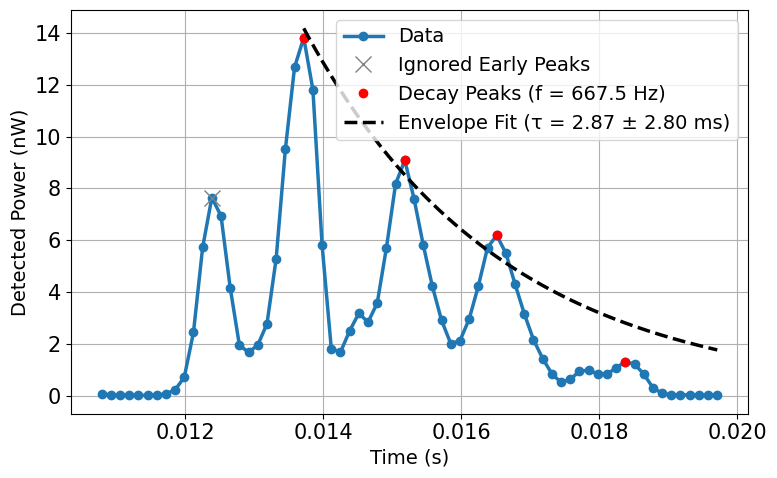

In [163]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# ==========================================
# 1. LOAD YOUR DATA
# ==========================================
power = 10 ** (y[idx] / 10) * 1e6
t = tax[idx]

# ==========================================
# 2. PEAK DETECTION & RINGING FREQUENCY
# ==========================================
peaks, _ = find_peaks(power, height=0.6, distance=10)

peak_times = t[peaks]
periods = np.diff(peak_times)  # Δt between peaks
mean_period = np.mean(periods)  # Average period T
freq_peaks = 1.0 / mean_period  # Ringing frequency f = 1/T

print(f"Detected {len(peaks)} peaks")
print(f"Ringing Frequency: {freq_peaks:.2f} Hz\n")

# ==========================================
# 3. ENVELOPE DECAY FITTING
# ==========================================
# Find max peak and discard peaks prior to it
max_peak_idx_in_peaks = np.argmax(power[peaks])
decay_peaks = peaks[max_peak_idx_in_peaks:]
ignored_peaks = peaks[:max_peak_idx_in_peaks]

t_decay = t[decay_peaks]
power_decay = power[decay_peaks]


# Exponential decay model: P(t) = A * exp(-(t - t0) / tau) + C
def exp_decay(t_val, A, tau, C):
    return A * np.exp(-(t_val - t_decay[0]) / tau) + C


# Fit exponential curve to remaining peaks
if len(decay_peaks) >= 3:
    # Initial guess ensured to be >= 0
    p0 = [
        max(1e-9, power_decay[0] - max(0, np.min(power))),
        max(1e-9, (t_decay[-1] - t_decay[0]) / 2),
        max(0.0, np.min(power)),
    ]

    # Bounds: A >= 0, tau >= 0, C >= 0 (C is lower bounded by 0)
    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

    # Extract optimal parameters (popt) and covariance matrix (pcov)
    popt, pcov = curve_fit(
        exp_decay, t_decay, power_decay, p0=p0, bounds=bounds
    )
    A_fit, tau_fit, C_fit = popt

    # Standard errors (1-sigma standard deviation) from diagonal of pcov
    perr = np.sqrt(np.diag(pcov))
    tau_err = perr[1]

    # Generate smooth fit line
    t_fit_smooth = np.linspace(t_decay[0], t[-1], 200)
    power_fit_smooth = exp_decay(t_fit_smooth, *popt)

    print(
        f"Decay Time Constant (τ): {tau_fit * 1e3:.3f} ± {tau_err * 1e3:.3f} ms"
    )
    print(f"Initial Peak Amplitude (A): {A_fit:.2f} nW")
    print(f"Baseline Offset (C): {C_fit:.2f} nW")
else:
    print("Not enough decay peaks found to fit exponential curve.")
    tau_fit = None
    tau_err = None

# ==========================================
# 4. PLOTTING
# ==========================================
plt.figure(figsize=(8, 5))

# Plot raw signal
plt.plot(t, power, ".-", label="Data")

# Plot ignored early peaks (if any)
if len(ignored_peaks) > 0:
    plt.plot(
        t[ignored_peaks],
        power[ignored_peaks],
        "x",
        color="gray",
        label="Ignored Early Peaks",
    )

# Plot decay peaks with Ringing Frequency in label
plt.plot(
    t_decay,
    power_decay,
    "r.",
    label=f"Decay Peaks (f = {freq_peaks:.1f} Hz)",
)

# Plot fitted decay curve with Tau and its fitting error in label
if tau_fit is not None:
    plt.plot(
        t_fit_smooth,
        power_fit_smooth,
        "k--",
        label=f"Envelope Fit (τ = {tau_fit * 1e3:.2f} ± {tau_err * 1e3:.2f} ms)",
    )

plt.xlabel("Time (s)")
plt.ylabel("Detected Power (nW)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()